# Week 8 — live coding (completed)

**Social and Cultural Analytics (7AAVBCS5)**

The filled-in version of what we typed in the lecture.

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The module's data lives in a separate public repository so that this notebook
# works both on your own machine and on Colab.
DATA_REPO = "https://github.com/markjhill/7AAVBCS5-data.git"


def data_path(name: str) -> Path:
    """Return a usable path to a file or folder in the module's data folder.

    A notebook's "current folder" is wherever it was opened from, which differs
    between Positron and Colab and is the usual cause of FileNotFoundError. So
    rather than assuming, we search upwards for a `data` folder. If there isn't
    one -- which means we are on Colab -- the public data repository is
    downloaded once and used instead.

    Works for single files ("museum_data.csv") and for folders ("SUA").
    """
    here = Path.cwd()
    for candidate in (here, *here.parents):
        local = candidate / "data" / name
        if local.exists():
            return local

    downloaded = Path("7AAVBCS5-data")
    if not downloaded.is_dir():
        print("No local data folder found -- downloading the module data (once)...")
        subprocess.run(
            ["git", "clone", "--depth", "1", DATA_REPO, str(downloaded)],
            check=True,
        )
    target = downloaded / name
    if not target.exists():
        raise FileNotFoundError(f"{name!r} is not in the module data.")
    return target

## 1. A scatter plot

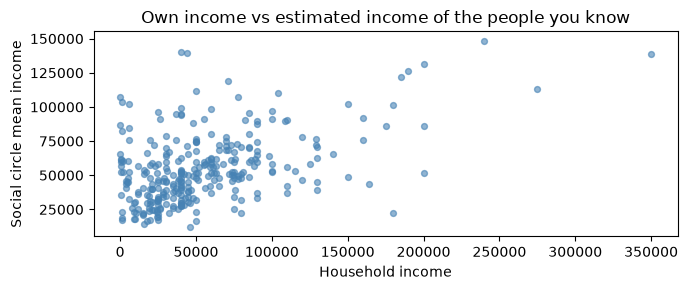

In [2]:
dawtry = pd.read_csv(data_path("DawtryEtAl2015.csv"))

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(dawtry["Household_Income"], dawtry["Social_Circle_Mean_Income"],
           color="steelblue", s=18, alpha=0.6)
ax.set_xlabel("Household income")
ax.set_ylabel("Social circle mean income")
ax.set_title("Own income vs estimated income of the people you know")
plt.tight_layout()
plt.show()

Positive, moderate, roughly linear, with some high outliers. Describe it before measuring it.

## 2. Pearson and Spearman

In [3]:
pair = dawtry[["Household_Income", "Social_Circle_Mean_Income"]].dropna()
print("n       :", len(pair))
print("Pearson :", round(pair["Household_Income"].corr(pair["Social_Circle_Mean_Income"]), 3))
print("Spearman:", round(pair["Household_Income"].corr(
    pair["Social_Circle_Mean_Income"], method="spearman"), 3))

n       : 301
Pearson : 0.475


Spearman: 0.405


r = 0.475 — moderate. This is the Dawtry et al. thesis: people generalise from the people they know.

### When they disagree

In [4]:
pair = dawtry[["Household_Income", "fairness"]].dropna()
print("Pearson :", round(pair["Household_Income"].corr(pair["fairness"]), 3))
print("Spearman:", round(pair["Household_Income"].corr(pair["fairness"], method="spearman"), 3))
print("minimum income:", dawtry["Household_Income"].min())

Pearson : 0.174
Spearman: 0.234
minimum income: 20.0


Pearson 0.174, Spearman 0.234. The gap is caused by the skew and by the implausible low values we
found in Week 7 — the minimum is £20.

Pearson uses the values; Spearman uses the ranks. When they disagree, look at the distribution.

## 3. A third variable

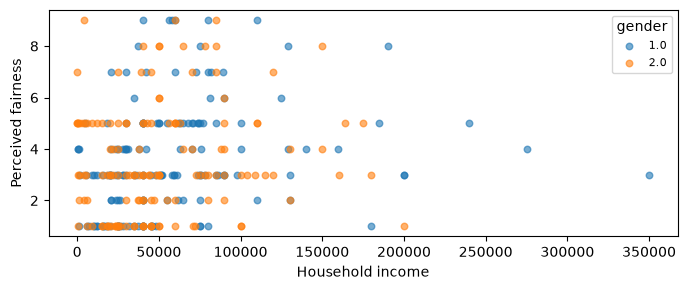

In [5]:
sub = dawtry[["Household_Income", "fairness", "gender"]].dropna()
fig, ax = plt.subplots(figsize=(7, 3))
for name, grp in sub.groupby("gender"):
    ax.scatter(grp["Household_Income"], grp["fairness"], label=str(name), alpha=0.6, s=22)
ax.set_xlabel("Household income")
ax.set_ylabel("Perceived fairness")
ax.legend(title="gender", fontsize=8)
plt.tight_layout()
plt.show()

Colouring by category is how you look for Simpson's Paradox — a relationship that reverses inside
the groups. Here it does not, which is the usual result.

## 4. A real null

In [6]:
s = dawtry[["age", "Household_Income"]].dropna()
print("n =", len(s), "| r =", round(s["age"].corr(s["Household_Income"]), 3))

n = 300 | r = 0.018


r = 0.018. Essentially nothing.

Report it as: *in this sample, age and household income were essentially uncorrelated
(r = 0.02, n = 300)*. Not "there is no relationship" — that is a claim about the world.

## 5. Anscombe

In [7]:
x1 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
x4 = [8] * 8 + [19, 8, 8]
sets = {
    "I":   (x1, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    "II":  (x1, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    "III": (x1, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    "IV":  (x4, [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 5.56, 12.50, 7.91, 6.89]),
}

for k, (x, y) in sets.items():
    print(f"set {k:3} mean x {pd.Series(x).mean():.2f}  mean y {pd.Series(y).mean():.2f} "
          f" r {pd.Series(x).corr(pd.Series(y)):.3f}")

set I   mean x 9.00  mean y 7.50  r 0.816
set II  mean x 9.00  mean y 7.50  r 0.816
set III mean x 9.00  mean y 7.50  r 0.816
set IV  mean x 9.00  mean y 7.50  r 0.817


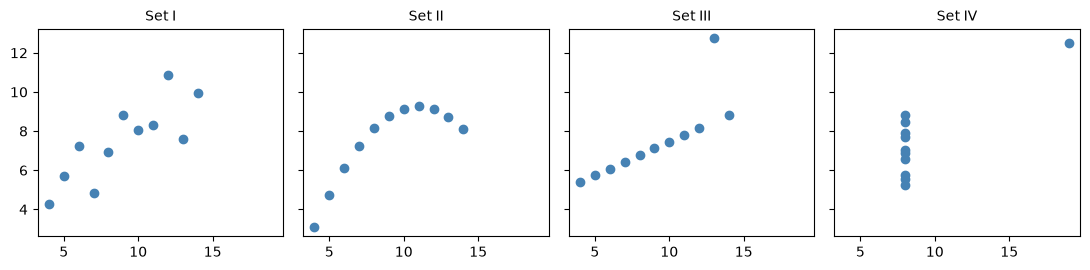

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharex=True, sharey=True)
for ax, (name, (x, y)) in zip(axes, sets.items()):
    ax.scatter(x, y, color="steelblue")
    ax.set_title(f"Set {name}", fontsize=10)
plt.tight_layout()
plt.show()

Identical statistics, four different stories. Plot your data before you summarise it.

End of live coding.